In [5]:
import sys
print(sys.executable)

c:\Users\gabri\AppData\Local\Programs\Python\Python311\python.exe


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE 

In [42]:
df = pd.read_csv('../data/processed/processed_genz_mental_wellness_synthetic_dataset.csv')

In [43]:
X, y = df.drop(columns=['Burnout_Risk']), df['Burnout_Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [44]:
print("Class Distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class Distribution after SMOTE:")
print(y_train_smote.value_counts())

Class Distribution before SMOTE:
Burnout_Risk
High      3753
Medium    3200
Low         47
Name: count, dtype: int64
Class Distribution after SMOTE:
Burnout_Risk
High      3753
Medium    3753
Low       3753
Name: count, dtype: int64


##### KNN Classifier 

In [45]:
print(f"Training KNN without SMOTE")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))

print(f"Training KNN with SMOTE")
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn_smote.predict(X_test)
print(classification_report(y_test, y_pred_knn_smote))

Training KNN without SMOTE
              precision    recall  f1-score   support

        High       0.93      0.93      0.93      1635
         Low       1.00      0.18      0.30        17
      Medium       0.91      0.91      0.91      1348

    accuracy                           0.92      3000
   macro avg       0.95      0.67      0.71      3000
weighted avg       0.92      0.92      0.92      3000

Training KNN with SMOTE
              precision    recall  f1-score   support

        High       0.94      0.91      0.92      1635
         Low       0.38      0.88      0.54        17
      Medium       0.89      0.91      0.90      1348

    accuracy                           0.91      3000
   macro avg       0.74      0.90      0.79      3000
weighted avg       0.91      0.91      0.91      3000



##### Random Forest Classifier 

In [46]:
print(f"Training Radom Forest without SMOTE")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

print(f"Training Radom Forest with SMOTE")
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)
print(classification_report(y_test, y_pred_rf_smote))

Training Radom Forest without SMOTE


              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1635
         Low       1.00      0.94      0.97        17
      Medium       1.00      1.00      1.00      1348

    accuracy                           1.00      3000
   macro avg       1.00      0.98      0.99      3000
weighted avg       1.00      1.00      1.00      3000

Training Radom Forest with SMOTE
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1635
         Low       1.00      1.00      1.00        17
      Medium       1.00      1.00      1.00      1348

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



##### Decision Tree Classifier 

In [47]:
print(f"Training Decision Tree without SMOTE")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print(classification_report(y_test, y_pred))

print(f"Training Decision Tree with SMOTE")
dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)
y_pred_dt_smote = dt_smote.predict(X_test)
print(classification_report(y_test, y_pred_dt_smote))

Training Decision Tree without SMOTE
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1635
         Low       1.00      0.94      0.97        17
      Medium       1.00      1.00      1.00      1348

    accuracy                           1.00      3000
   macro avg       1.00      0.98      0.99      3000
weighted avg       1.00      1.00      1.00      3000

Training Decision Tree with SMOTE
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1635
         Low       1.00      0.94      0.97        17
      Medium       1.00      1.00      1.00      1348

    accuracy                           1.00      3000
   macro avg       1.00      0.98      0.99      3000
weighted avg       1.00      1.00      1.00      3000



##### Logistic Regression Classifier 

In [48]:
print(f"Training Logistic Regression without SMOTE")
lg = LogisticRegression(random_state=42)
lg.fit(X_train, y_train)
y_pred = lg.predict(X_test)
print(classification_report(y_test, y_pred))

print(f"Training Logistic Regression with SMOTE")
lg_smote = LogisticRegression(random_state=42)
lg_smote.fit(X_train_smote, y_train_smote)
y_pred_lg_smote = lg_smote.predict(X_test)
print(classification_report(y_test, y_pred_lg_smote))

Training Logistic Regression without SMOTE


c:\Users\gabri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

        High       0.98      0.98      0.98      1635
         Low       0.41      0.41      0.41        17
      Medium       0.96      0.97      0.96      1348

    accuracy                           0.97      3000
   macro avg       0.78      0.78      0.78      3000
weighted avg       0.97      0.97      0.97      3000

Training Logistic Regression with SMOTE
              precision    recall  f1-score   support

        High       0.97      0.96      0.96      1635
         Low       0.50      0.76      0.60        17
      Medium       0.95      0.95      0.95      1348

    accuracy                           0.95      3000
   macro avg       0.80      0.89      0.84      3000
weighted avg       0.96      0.95      0.95      3000



c:\Users\gabri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### Visual Representation Results

In [51]:
def plot_confusion_matrix(name ,model, y_test, y_pred):
    
    print(f"Confusion Matrix for {name} Model:")

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

Confusion Matrix for KNN Model:


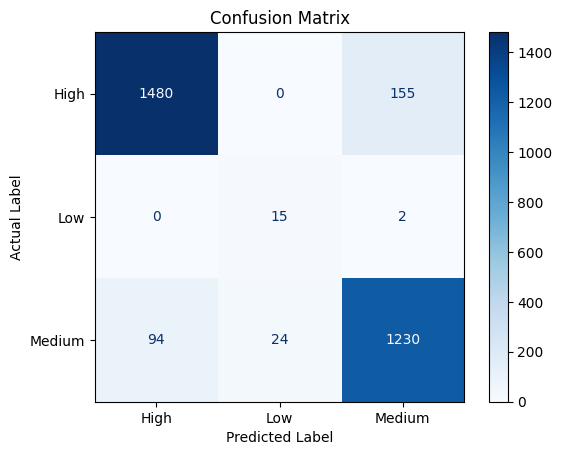

Confusion Matrix for Random Forest Model:


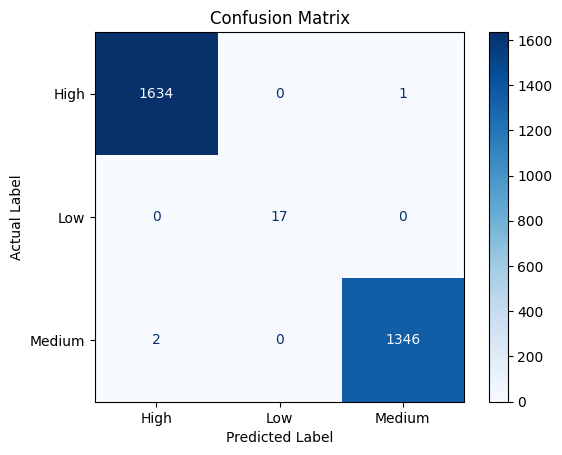

Confusion Matrix for Decision Tree Model:


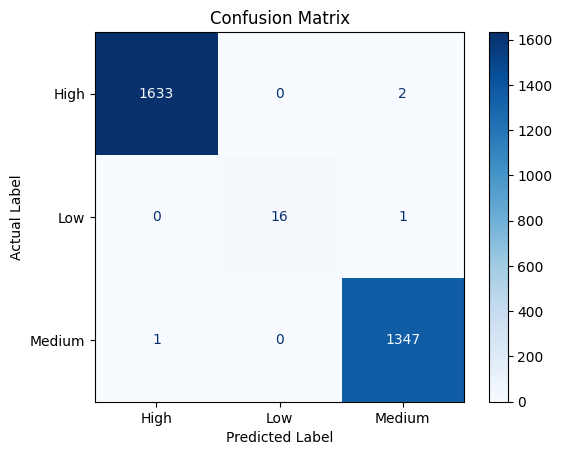

Confusion Matrix for Logistic Regression Model:


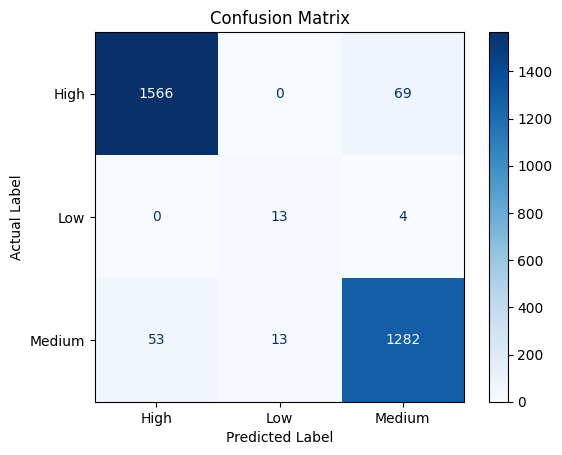

In [52]:
plot_confusion_matrix("KNN", knn_smote, y_test, y_pred_knn_smote)
plot_confusion_matrix("Random Forest", rf_smote, y_test, y_pred_rf_smote)
plot_confusion_matrix("Decision Tree", dt_smote, y_test, y_pred_dt_smote)
plot_confusion_matrix("Logistic Regression", lg_smote, y_test, y_pred_lg_smote)